# Momepy roads - Berlin

This notebook uses momepy to calculate geometrical and topological features of the Berlin street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (node-based, local radius 500 m, propagated to edges via mean_nodes)
- **Closeness centrality** -- extended local (radius 800 m) and local 400 m
- **Straightness centrality** (node-based, local radius 500 m)

Input: `BER_noise_streets.gpkg` -- the 70890 Berlin OSM drive streets with projected noise values.

Note on radii: Berlin has ~28k nodes and ~71k edges. Global betweenness/closeness are intractable
(hours on a single CPU). Local-radius variants (500 m betweenness/straightness, 800 m closeness)
capture the same urban morphology signal and complete in a few minutes each.

## Import libraries

In [1]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'BER_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:25833
(70890, 12)
['segment_id', 'highway', 'name', 'length', 'GES_DEN_mean', 'GES_N_mean', 'noise_day', 'noise_evening', 'noise_night', 'n_points', 'distance', 'geometry']
Number of street segments: 70890


In [3]:
place_name = 'Berlin, Germany'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
display(buildings.head(3))

Downloaded 503022 buildings.


geometry addr:city  \
element  id                                                                  
relation 3197  POLYGON ((385399.157 5816830.057, 385403.657 5...       NaN   
         3212  POLYGON ((386524.588 5826152.311, 386525.029 5...    Berlin   
         3215  POLYGON ((382885.701 5819074.09, 382886.065 58...    Berlin   

              addr:housenumber addr:postcode      addr:street amenity  \
element  id                                                             
relation 3197              NaN           NaN              NaN     NaN   
         3212               67         13403  Kienhorststraße     NaN   
         3215             8-14         14057     Masurenallee     NaN   

              building name short_name  url  ... nudism branch:en check_in  \
element  id                                  ...                             
relation 3197   public  NaN        NaN  NaN  ...    NaN       NaN      NaN   
         3212   school  NaN        NaN  NaN  ...    NaN       NaN      NaN   
         3215   office  NaN        NaN  NaN  ...    NaN       NaN      NaN   

              dog:fee note:payment:cash source:access:password  \
element  id                                                      
relation 3197     NaN               NaN                    NaN   
         3212     NaN               NaN                    NaN   
         3215     NaN               NaN                    NaN   

              source:internet_access:password changing_table:location:notes  \
element  id                                                                   
relation 3197                             NaN                           NaN   
         3212                             NaN                           NaN   
         3215                             NaN                           NaN   

              was:content was:man_made  
element  id                             
relation 3197         NaN          NaN  
         3212         NaN          NaN  
         3215         NaN          NaN  

[3 rows x 1348 columns]

## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


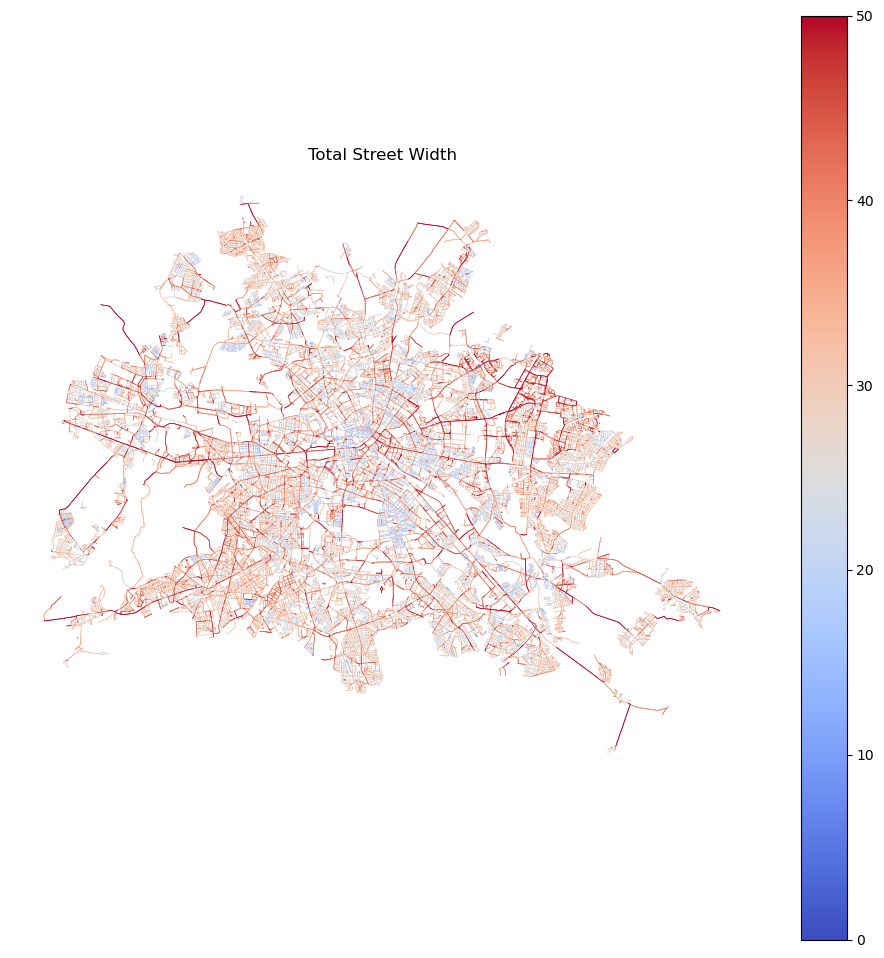

In [6]:
ax = edges.plot(cmap='coolwarm', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

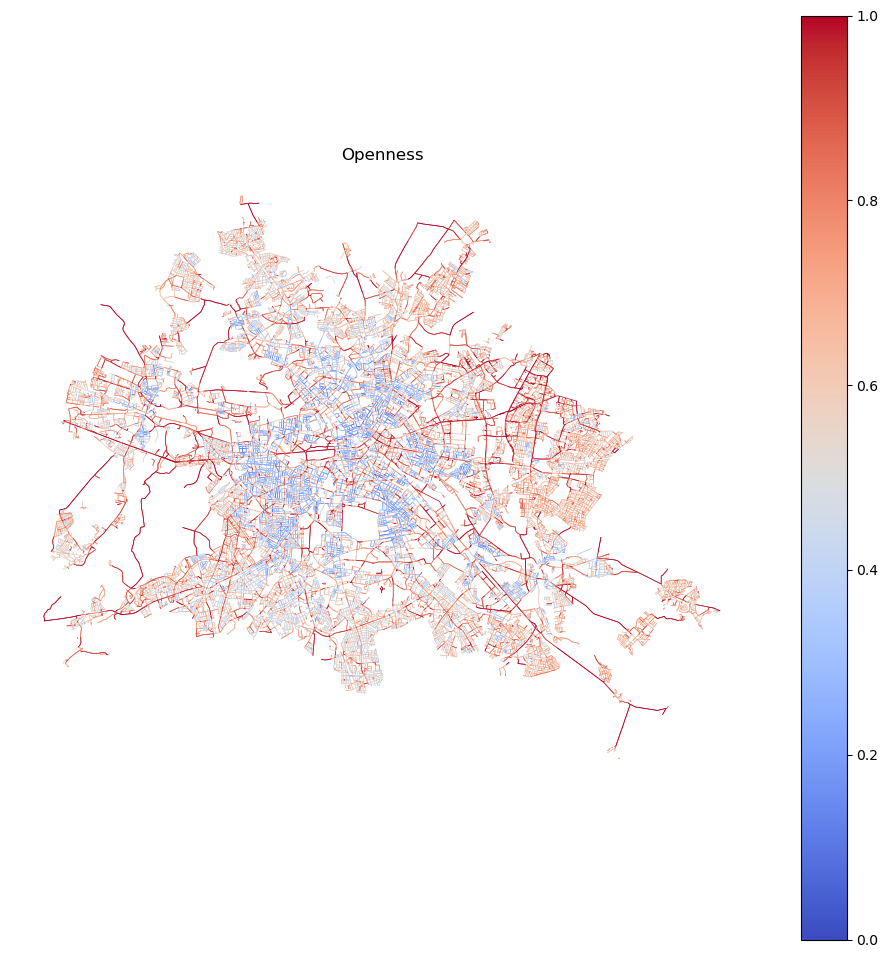

In [7]:
ax = edges.plot(cmap='coolwarm', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [8]:
primal = mm.gdf_to_nx(edges, approach='primal')
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 27898   edges: 70890


## Betweenness Centrality (node-based, radius 500 m)

In [9]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='nodes',
    weight='mm_len', radius=500, distance='mm_len'
)

  0%|          | 0/27898 [00:00<?, ?it/s]

In [10]:
# Propagate node betweenness to edges (mean of the two endpoint nodes)
mm.mean_nodes(betweenness, 'betweenness_metric_e')
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,177.0
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,177.0
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,13.5
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,13.5
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,22.5


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

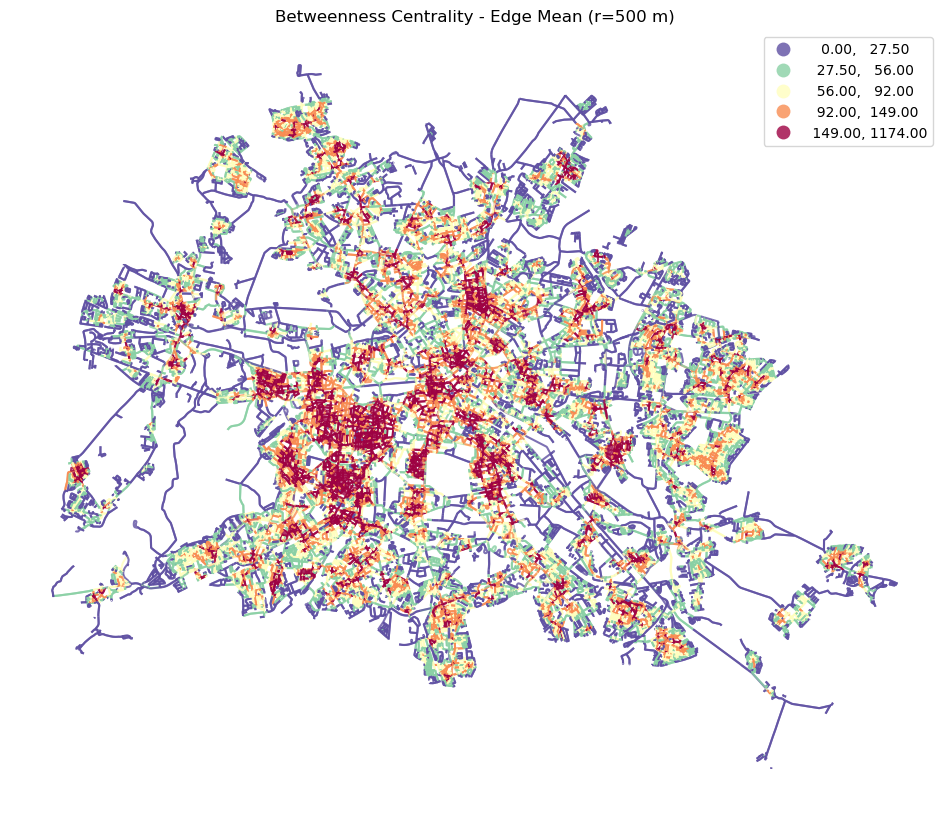

In [11]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality (extended local, radius 800 m)

Careful, takes a few minutes

In [12]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len',
    radius=800, distance='mm_len'
)

  0%|          | 0/27898 [00:00<?, ?it/s]

In [13]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27898 entries, 0 to 27897
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 27898 non-null  float64 
 1   y                 27898 non-null  float64 
 2   closeness_global  27898 non-null  float64 
 3   nodeID            27898 non-null  int64   
 4   geometry          27898 non-null  geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 1.1 MB


Text(0.5, 1.0, 'Closeness Centrality - Node Based (r=800 m)')

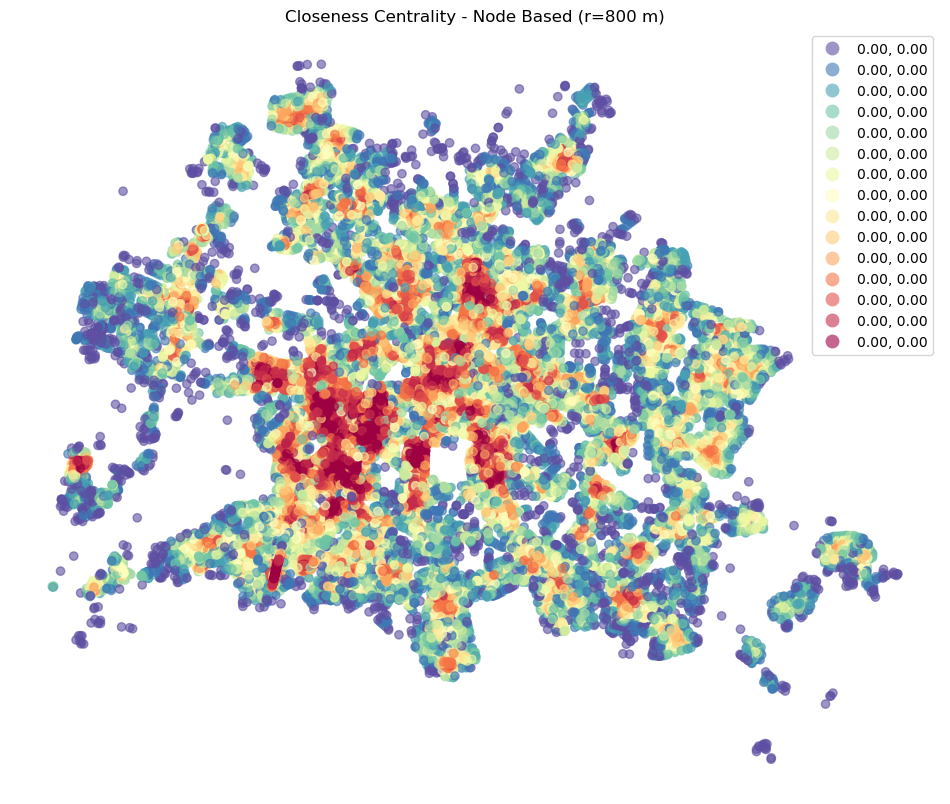

In [14]:
ax = nodes.plot(
    column='closeness_global',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title('Closeness Centrality - Node Based (r=800 m)')

In [15]:
mm.mean_nodes(closeness, 'closeness_global')

In [16]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,closeness_global
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.000005
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.000005
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.000003
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.000003
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.000002


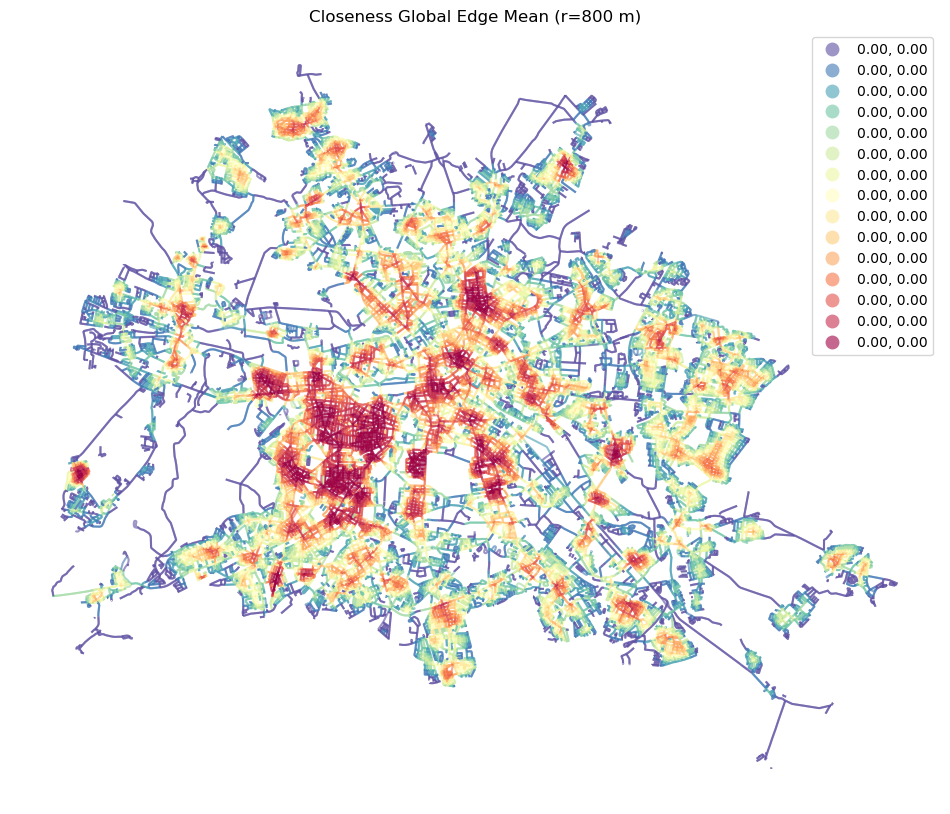

In [17]:
ax = primal_gdf_clos.plot(
    column='closeness_global',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title('Closeness Global Edge Mean (r=800 m)')

## Local Closeness Centrality (radius 400 m)

In [18]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/27898 [00:00<?, ?it/s]

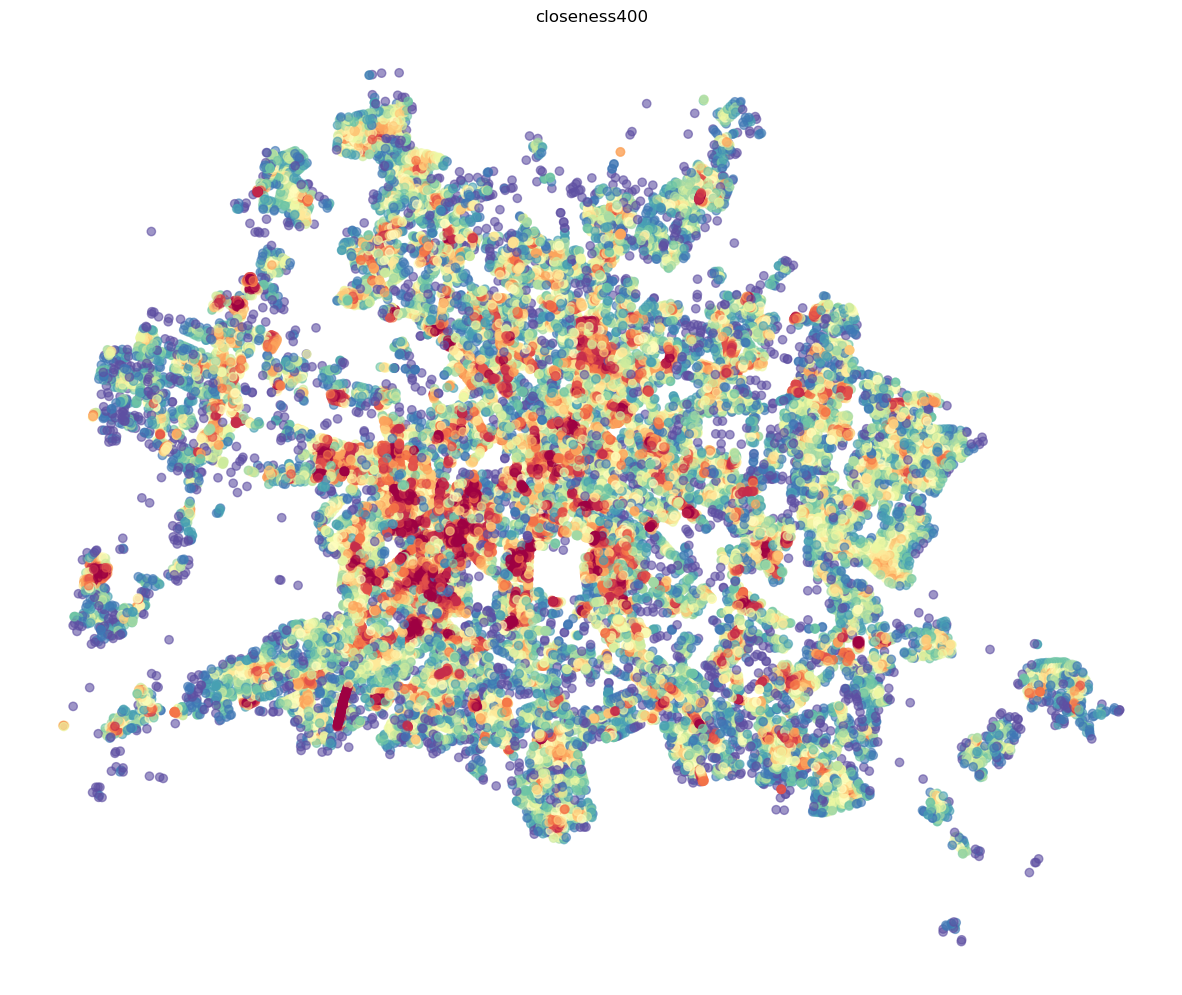

In [19]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column='closeness400',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('closeness400')

In [20]:
mm.mean_nodes(local_clos, 'closeness400')

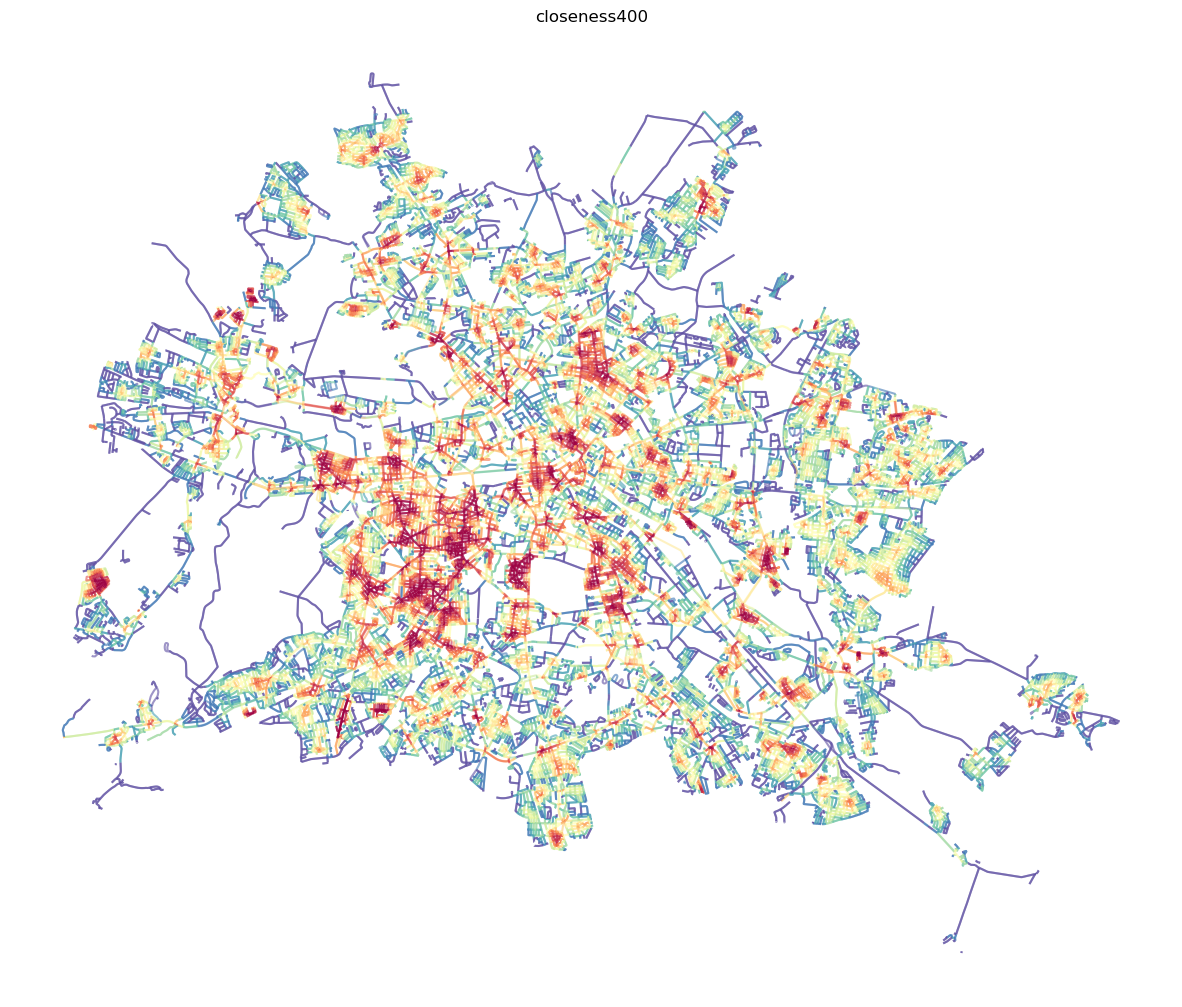

In [21]:
local_clos_gdf = mm.nx_to_gdf(local_clos, points=False)

ax = local_clos_gdf.plot(
    column='closeness400',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('closeness400')

## Straightness (node-based, radius 500 m)

In [22]:
straighteness = mm.straightness_centrality(
    primal, radius=500, distance='mm_len'
)

  0%|          | 0/27898 [00:00<?, ?it/s]

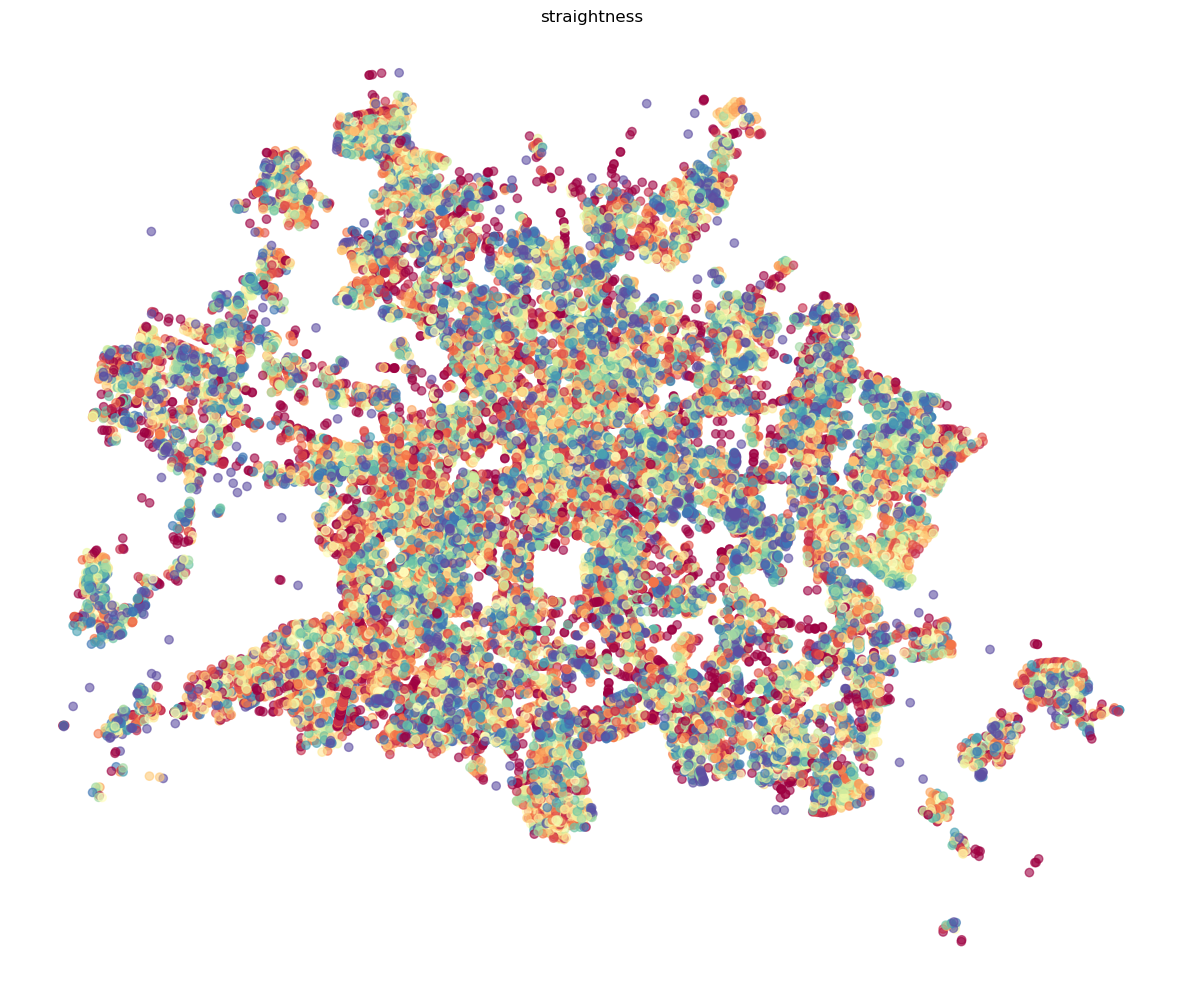

In [23]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column='straightness',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title('straightness')

In [24]:
mm.mean_nodes(straighteness, 'straightness')

In [25]:
primal_gdf_straight = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_straight.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,straightness
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.904821
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.904821
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.933794
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.933794
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.886788


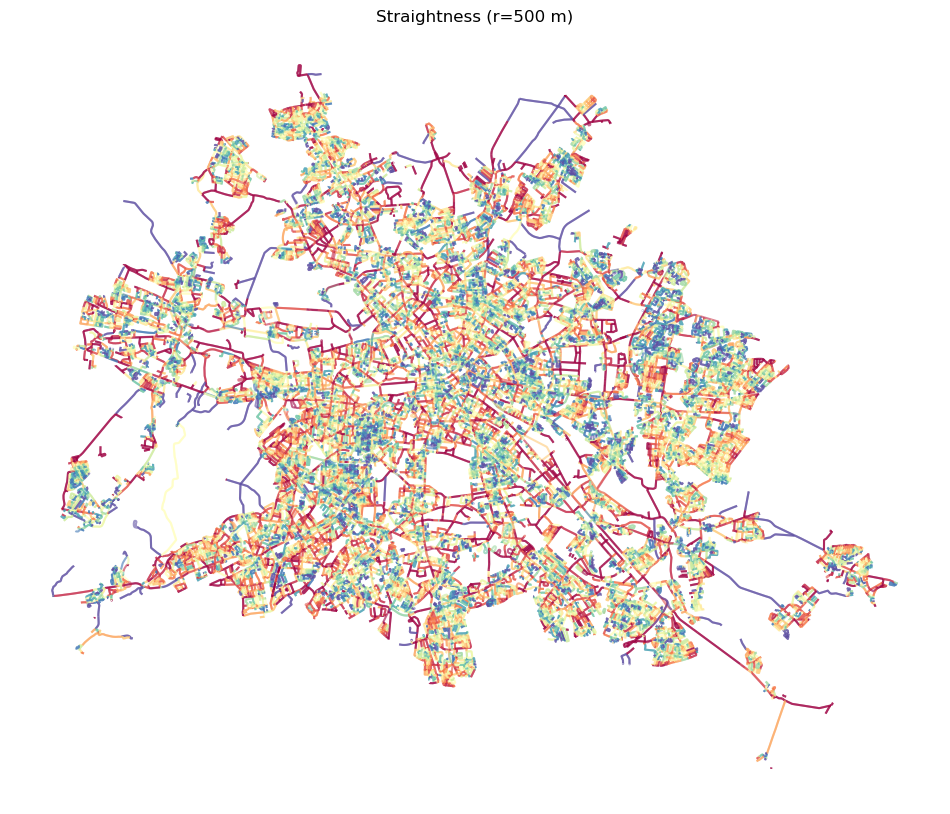

In [26]:
ax = primal_gdf_straight.plot(
    column='straightness',
    cmap='Spectral_r',
    scheme='quantiles',
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title('Straightness (r=500 m)')

## Merge all centrality features

Combine width/openness (from street profile), betweenness, closeness and straightness
into a single edge GeoDataFrame keyed by `segment_id`.

In [27]:
# primal_gdf_straight carries width, openness and other profile columns because
# mm.gdf_to_nx preserves all edge attributes from the input GDF
primal_gdf = primal_gdf_straight.copy()

def _safe_merge(base, other, col):
    if 'segment_id' in other.columns and 'segment_id' in base.columns:
        return base.merge(other[['segment_id', col]], on='segment_id', how='left')
    base = base.copy()
    base[col] = other[col].values
    return base

primal_gdf = _safe_merge(primal_gdf, primal_gdf_betw, 'betweenness_metric_e')
primal_gdf = _safe_merge(primal_gdf, primal_gdf_clos, 'closeness_global')
primal_gdf = _safe_merge(primal_gdf, local_clos_gdf, 'closeness400')

print(primal_gdf.columns.tolist())
primal_gdf.head()

['segment_id', 'highway', 'name', 'length', 'GES_DEN_mean', 'GES_N_mean', 'noise_day', 'noise_evening', 'noise_night', 'n_points', 'distance', 'geometry', 'width', 'openness', 'width_deviation', 'mm_len', 'straightness', 'betweenness_metric_e', 'closeness_global', 'closeness400']


,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,straightness,betweenness_metric_e,closeness_global,closeness400
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.904821,177.0,0.000005,2.819245e-06
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.904821,177.0,0.000005,2.819245e-06
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.933794,13.5,0.000003,6.748056e-07
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.933794,13.5,0.000003,6.748056e-07
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.886788,22.5,0.000002,7.868624e-07


## Merge with noise dataset

In [28]:
noise_dataset = pd.read_csv('data/osm_roads_noise_class.csv')

if 'segment_id' in primal_gdf.columns:
    merged = noise_dataset.merge(
        primal_gdf[['segment_id', 'closeness400']].rename(columns={'segment_id': 'road_id'}),
        on='road_id', how='left'
    )
else:
    merged = noise_dataset.copy()

merged.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street,closeness400
0,172539_172562_0,2,2,1,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539,2.819245e-06
1,172539_34694336_0,2,2,1,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362,6.748056e-07
2,172539_34694265_0,2,2,1,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362,7.868624e-07
3,172545_271370539_0,3,3,2,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367,1.828302e-06
4,172545_34694336_0,2,2,1,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367,1.431952e-06


## Create data frame

In [32]:
def _col(gdf, col):
    """Return column if present, else a zeros Series."""
    return gdf[col] if col in gdf.columns else pd.Series(0.0, index=gdf.index)

dataset = pd.DataFrame({
    'road_id':         _col(primal_gdf, 'segment_id'),
    'width':           _col(primal_gdf, 'width'),
    'openness':        _col(primal_gdf, 'openness'),
    'height':          _col(primal_gdf, 'height'),
    'betweenness': _col(primal_gdf, 'betweenness_metric_e'),
    'closeness_global': _col(primal_gdf, 'closeness_global'),
    'closeness400':    _col(primal_gdf, 'closeness400'),
    'straightness':    _col(primal_gdf, 'straightness'),
}).fillna(0)

dataset.head()

,road_id,width,openness,height,betweenness,closeness_global,closeness400,straightness
0,172539_172562_0,28.940821,0.728070,0.0,177.0,0.000005,2.819245e-06,0.904821
1,172562_172539_0,28.942026,0.728070,0.0,177.0,0.000005,2.819245e-06,0.904821
2,172539_34694336_0,43.648847,0.924419,0.0,13.5,0.000003,6.748056e-07,0.933794
3,34694336_172539_0,43.648664,0.924419,0.0,13.5,0.000003,6.748056e-07,0.933794
4,172539_34694265_0,37.132640,0.797297,0.0,22.5,0.000002,7.868624e-07,0.886788


## Export dataset to CSV

In [33]:
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, 'momepy_roads_features.csv'), index=False)
print('Exported momepy_roads_features.csv')

Exported momepy_roads_features.csv
